In [2]:
print("Outfit Recommender V6 - Hybrid Deep Learning + Manual Features")

Outfit Recommender V6 - Hybrid Deep Learning + Manual Features


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image

In [4]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

print("MobileNetV2 loaded successfully")

C:\Users\ousama\AppData\Local\Temp\ipykernel_20996\2553550147.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


MobileNetV2 loaded successfully


In [5]:
IMAGE_FOLDER = "../images"

files = [
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
]

print("Number of images:", len(files))
print(files[:5])

Number of images: 95
['#outfits #fashion #summer #summerstyle.jpg', '#StylishWoman.jpg', '14+ Inspiring Minimalist Fashion Ideas For Men.jpg', '20 Western Fall Outfits for Women in 2025 That Are Equal Parts Cute and Comfy.webp', "2024 Men's Streetwear Guide_ 20 Trendsetting Styles & Fashion Tips - Elevate Your Wardrobe!.jpg"]


In [6]:
def extract_deep_features(img_path, model):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    features = model.predict(img_array, verbose=0)

    return features.flatten()

In [7]:
def extract_manual_features(img_path, n_colors=3):
    img = Image.open(img_path).convert("RGB")
    img = img.resize((100, 100))

    img_array = np.array(img)
    flat_pixels = img_array.reshape(-1, 3)

    # Dominant colors
    kmeans = KMeans(n_clusters=n_colors, random_state=42, n_init=10)
    kmeans.fit(flat_pixels)
    colors = kmeans.cluster_centers_.flatten()

    # Brightness
    brightness = np.mean(flat_pixels)

    # Contrast
    contrast = np.std(flat_pixels)

    # Grayscale for edge and texture
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

    # Edge density
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    # Texture
    texture = np.std(gray)

    manual_features = np.concatenate([
        colors,
        [brightness, contrast, edge_density, texture]
    ])

    return manual_features

In [8]:
deep_features_list = []
manual_features_list = []

for file in files:
    path = os.path.join(IMAGE_FOLDER, file)

    deep_features = extract_deep_features(path, base_model)
    manual_features = extract_manual_features(path)

    deep_features_list.append(deep_features)
    manual_features_list.append(manual_features)

deep_features_array = np.array(deep_features_list)
manual_features_array = np.array(manual_features_list)

print("Deep features shape:", deep_features_array.shape)
print("Manual features shape:", manual_features_array.shape)

Deep features shape: (95, 1280)
Manual features shape: (95, 13)


In [9]:
deep_scaler = StandardScaler()
manual_scaler = StandardScaler()

deep_scaled = deep_scaler.fit_transform(deep_features_array)
manual_scaled = manual_scaler.fit_transform(manual_features_array)

In [10]:
combined_features = np.concatenate([
    deep_scaled,
    manual_scaled
], axis=1)

print("Combined features shape:", combined_features.shape)

Combined features shape: (95, 1293)


In [11]:
def recommend_hybrid_outfits(input_image, top_n=5):
    input_deep = extract_deep_features(input_image, base_model)
    input_manual = extract_manual_features(input_image)

    input_deep_scaled = deep_scaler.transform([input_deep])
    input_manual_scaled = manual_scaler.transform([input_manual])

    input_combined = np.concatenate([
        input_deep_scaled,
        input_manual_scaled
    ], axis=1)

    similarities = cosine_similarity(
        input_combined,
        combined_features
    )[0]

    sorted_indexes = similarities.argsort()[::-1]

    shown = 0

    for index in sorted_indexes:
        file = files[index]

        if file == os.path.basename(input_image):
            continue

        score = similarities[index]
        img_path = os.path.join(IMAGE_FOLDER, file)
        img = Image.open(img_path).convert("RGB")

        print(f"{file} --> Hybrid Similarity: {score:.3f}")

        plt.imshow(img)
        plt.title(f"Hybrid Similarity: {score:.3f}")
        plt.axis("off")
        plt.show()

        shown += 1

        if shown >= top_n:
            break

#outfits #fashion #summer #summerstyle.jpg --> Hybrid Similarity: 0.223


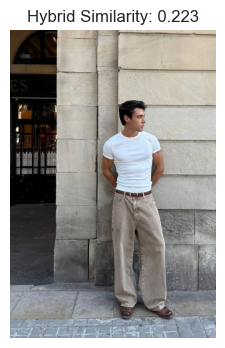

30 Effortlessly Chic Outfits to Copy for Summer.jpg --> Hybrid Similarity: 0.186


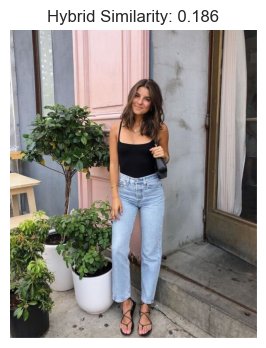

Effortless Minimal Street Style – Casual Beige Wide-Leg Pants Outfit.jpg --> Hybrid Similarity: 0.174


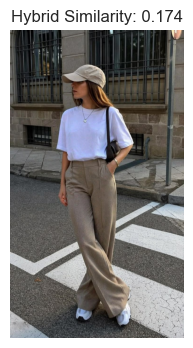

Trendy Streetwear Outfit Ideas for Men _ Casual Oversized Hoodie Style.jpg --> Hybrid Similarity: 0.165


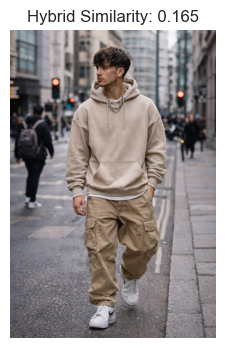

download (1).webp --> Hybrid Similarity: 0.159


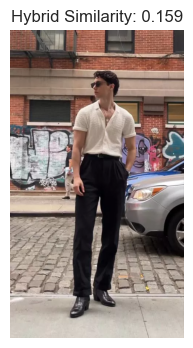

In [12]:
selected_image = r"C:\Users\ousama\Downloads\Fashion Color Analyzer\images\antonio medugno.jpg"

recommend_hybrid_outfits(selected_image, top_n=5)